## Load the tokenizer

In [5]:
import sys
sys.path.append('..')

In [6]:
from minbpe import BasicTokenizer

tokenizer = BasicTokenizer()
tokenizer.load(model_file="../output/tokenizer/my_tokenizer.model")


def get_vocab_size(tokenizer: BasicTokenizer) -> int:
    vocab = tokenizer.vocab
    special_tokens = tokenizer.special_tokens

    return len(vocab) + len(special_tokens)

## Create the model

In [7]:
import torch
torch.manual_seed(3647)

In [8]:
from transformer.model import GPTLanguageModel

block_size = 256
n_embd = 512
n_head = 8
n_layer = 4
dropout = 0.2
batch_size = 64
vocab_size = get_vocab_size(tokenizer)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = GPTLanguageModel(
    vocab_size=vocab_size,
    block_size=block_size,
    n_embd=n_embd,
    n_head=n_head,
    n_layer=n_layer,
    dropout=dropout,
    device=device
).to(device)
model = getattr(model, "__wrapped__", model)  # Ensure the raw model object is used
# model = torch.compile(model)  # Disabled on Windows unless MSVC compiler is installed

print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

13.795338 M parameters


## Data preparation

### 1. Load the data

In [9]:
with open("../output/combined_text.txt", "r", encoding='utf-8') as f:
    text_sequence = f.read()

encoded_text_sequence = tokenizer.encode(text_sequence)
len(encoded_text_sequence)

411925

### 2. Split it into train and test

In [10]:
data = torch.tensor(encoded_text_sequence, dtype=torch.long)
split_index = int(0.9 * len(data))
train_data = data[:split_index]
val_data = data[split_index:]

### 3. Data loader

In [11]:
from typing import Tuple
from torch.utils.data import Dataset, DataLoader


class TextDataset(Dataset):
    def __init__(self, data: torch.Tensor, block_size: int) -> None:
        if len(data) <= block_size:
            raise ValueError(
                f"The length of the data ({len(data)}) must be greater than the block_size ({block_size})."
            )

        self.data = data
        self.block_size = block_size

    def __len__(self) -> int:
        return len(self.data) - self.block_size

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        x = self.data[index : index + self.block_size]
        y = self.data[index + 1 : index + self.block_size + 1]
        return x, y


def get_dataloaders(
    train_data: torch.Tensor,
    val_data: torch.Tensor,
    block_size: int,
    batch_size: int,
    device: torch.device,
) -> Tuple[DataLoader, DataLoader]:
    train_dataset = TextDataset(train_data.to(device), block_size)
    val_dataset = TextDataset(val_data.to(device), block_size)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    return train_loader, val_loader

In [12]:
train_loader, val_loader = get_dataloaders(
    train_data=train_data,
    val_data=val_data,
    block_size=block_size,
    batch_size=batch_size,
    device=device,
)
x, y = next(iter(train_loader))
x.shape, y.shape

(torch.Size([64, 256]), torch.Size([64, 256]))

### 4. Training

In [13]:
from typing import Dict


@torch.no_grad()
def estimate_loss(
    model: torch.nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    eval_iters: int
) -> Dict[str, float]:
    output = {}
    model.eval()

    for split, loader in [('train', train_loader), ('val', val_loader)]:
        losses = torch.zeros(eval_iters)
        for i, (x, y) in enumerate(loader):
            if i >= eval_iters:
                break
            with torch.no_grad():
                _, loss = model(x, y)
            losses[i] = loss.item()
        output[split] = losses.mean().item()

    model.train()
    return output

In [14]:
def save_checkpoint(
    model: GPTLanguageModel,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    loss: float,
    file_path: str = "checkpoint.pth"
) -> None:
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss
    }
    torch.save(checkpoint, file_path)

In [26]:
import torch
import torch.nn as nn
import os
os.makedirs("../output/pre_training/run_4", exist_ok=True)
max_iters = 50
eval_interval = 1
eval_iters = 50
learning_rate = 3e-4

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
train_loader, val_loader = get_dataloaders(
    train_data=train_data,
    val_data=val_data,
    block_size=block_size,
    batch_size=batch_size,
    device=device
)
model.train()
train_losses = []
val_losses = []

for iteration in range(max_iters):
    for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
        # Evaluation
        if batch_idx % eval_interval == 0 or batch_idx == len(train_loader) - 1:
            losses = estimate_loss(
                model=model,
                train_loader=train_loader,
                val_loader=val_loader,
                eval_iters=min(eval_iters, len(val_loader))
            )
            train_losses.append(losses['train'])
            val_losses.append(losses['val'])

            print(
                f"iteration {iteration} / step {batch_idx}: "
                f"train loss {losses['train']:.4f}, "
                f"val loss {losses['val']:.4f}"
            )

        # Training step
        logits, loss = model(x_batch, y_batch)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    # Save checkpoint
    save_checkpoint(
        model=model,
        optimizer=optimizer,
        epoch=iteration,
        loss=loss.item(),
        file_path=f"../output/pre_training/run_4/checkpoint_{iteration}.pth"
    )

iteration 0 / step 0: train loss 4.8303, val loss 4.7976
iteration 0 / step 1: train loss 5.0402, val loss 5.0015
iteration 0 / step 2: train loss 4.9341, val loss 4.9175
iteration 0 / step 3: train loss 4.8912, val loss 4.8635
iteration 0 / step 4: train loss 4.8736, val loss 4.8194
iteration 0 / step 5: train loss 4.8610, val loss 4.8014
iteration 0 / step 6: train loss 4.8296, val loss 4.7966
iteration 0 / step 7: train loss 4.8389, val loss 4.7861
iteration 0 / step 8: train loss 4.8129, val loss 4.7714
iteration 0 / step 9: train loss 4.8052, val loss 4.7603
iteration 0 / step 10: train loss 4.7945, val loss 4.7531
iteration 0 / step 11: train loss 4.7880, val loss 4.7465
iteration 0 / step 12: train loss 4.7821, val loss 4.7406
iteration 0 / step 13: train loss 4.7689, val loss 4.7326
iteration 0 / step 14: train loss 4.7581, val loss 4.7270
iteration 0 / step 15: train loss 4.7592, val loss 4.7203
iteration 0 / step 16: train loss 4.7498, val loss 4.7146
iteration 0 / step 17: t

KeyboardInterrupt: 

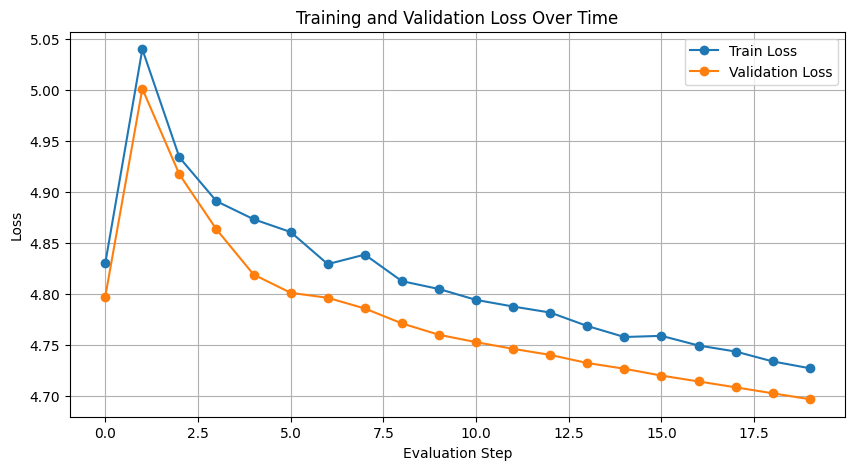

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Validation Loss", marker='o')
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Time")
plt.legend()
plt.grid()
plt.show()

In [29]:
input_tokens = tokenizer.encode("vro")
input_tokens = torch.tensor(
    input_tokens, dtype=torch.long).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model.generate(input_tokens=input_tokens, max_new_tokens=100)

print(tokenizer.decode(output[0].tolist()))

vroll in Fesoon from haictickfor an what is that We is and detic like Eo Thame Its chat if If you out Oh Is When ting shirl how not like if aheem were vieed to spon? I canss u short inder max have more pretty Im gay which pintorithing first should i guy To can just do that pretty too much min bro should row 
